# 09 — Fine-tune Strategy E on New_Plant_Diseases_Dataset & Test on Held-out Set

## Overview

This notebook has **two stages**:

| Stage | What happens |
|---|---|
| **A — Fine-tune** | Load `model_E_selective_V3_final.h5`, unfreeze the top layers, and fine-tune on `New_Plant_Diseases_Dataset/train` (18 345 tomato images across 10 classes) using `valid` as the validation split. |
| **B — Test** | Evaluate the newly saved model on `New_Plant_Diseases_Dataset/test/test/` — a flat folder of 16 tomato images with class names encoded in filenames. |

### Why fine-tune instead of train from scratch?
`model_E_selective_V3_final.h5` already has a strong feature extractor.  
Fine-tuning on New_Plant_Diseases_Dataset aligns those features with the  
richer, higher-volume dataset (~18 k images vs ~7 k before) while  
keeping training time short.

### Dataset layout
```
New_Plant_Diseases_Dataset/
    train/   ← 18 345 tomato images, 10 classes (subfolder per class)
    valid/   ← 4 585 tomato images, same structure
    test/
        test/ ← 16 tomato images, flat (no subfolders), class in filename
```

### Class mapping (alphabetical — same as original training)
| Index | Folder name |
|---|---|
| 0 | Tomato___Bacterial_spot |
| 1 | Tomato___Early_blight |
| 2 | Tomato___Late_blight |
| 3 | Tomato___Leaf_Mold |
| 4 | Tomato___Septoria_leaf_spot |
| 5 | Tomato___Spider_mites Two-spotted_spider_mite |
| 6 | Tomato___Target_Spot |
| 7 | Tomato___Tomato_Yellow_Leaf_Curl_Virus |
| 8 | Tomato___Tomato_mosaic_virus |
| 9 | Tomato___healthy |


In [7]:
# ============================================================
# Cell 1 — Imports
# ============================================================

import os
import warnings
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
)

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

print('✅ All imports successful!')
print(f'   TensorFlow : {tf.__version__}')
print(f'   NumPy      : {np.__version__}')
print(f'   GPU        : {tf.config.list_physical_devices("GPU")}')


✅ All imports successful!
   TensorFlow : 2.16.2
   NumPy      : 1.26.4
   GPU        : []


In [8]:
# ============================================================
# Cell 2 — Paths & Configuration
# ============================================================

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / 'dataset').exists():
    REPO_ROOT = REPO_ROOT.parent

# New_Plant_Diseases_Dataset splits
NPDD_ROOT  = REPO_ROOT / 'validation' / 'New_Plant_Diseases_Dataset'
TRAIN_DIR  = NPDD_ROOT / 'train'
VALID_DIR  = NPDD_ROOT / 'valid'
TEST_DIR   = NPDD_ROOT / 'test' / 'test'   # flat folder, class in filename

# Models
MODELS_DIR        = REPO_ROOT / 'models'
BASE_MODEL_PATH   = MODELS_DIR / 'model_E_selective_V3_final.h5'
FINETUNED_PATH    = MODELS_DIR / 'model_E_finetuned_NPDD_final.h5'
CHECKPOINT_PATH   = MODELS_DIR / 'model_E_finetuned_NPDD_best.h5'

# Output directory for plots / CSVs
OUTPUT_DIR = REPO_ROOT / 'outputs' / 'npdd_validation'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Training hyper-parameters
IMAGE_SIZE    = (224, 224)
BATCH_SIZE    = 32
NUM_CLASSES   = 10
FINETUNE_LR   = 1e-5        # lower LR for fine-tuning
UNFREEZE_LAST = 30          # unfreeze last N layers of MobileNetV2 base
EPOCHS        = 10          # EarlyStopping will likely stop earlier
LABEL_SMOOTH  = 0.1

# Class names — alphabetical order (matches ImageDataGenerator)
CLASS_NAMES = [
    'Bacterial Spot',         # 0  Tomato___Bacterial_spot
    'Early Blight',           # 1  Tomato___Early_blight
    'Late Blight',            # 2  Tomato___Late_blight
    'Leaf Mold',              # 3  Tomato___Leaf_Mold
    'Septoria Leaf Spot',     # 4  Tomato___Septoria_leaf_spot
    'Spider Mites',           # 5  Tomato___Spider_mites ...
    'Target Spot',            # 6  Tomato___Target_Spot
    'Yellow Leaf Curl',       # 7  Tomato___Tomato_Yellow_Leaf_Curl_Virus
    'Mosaic Virus',           # 8  Tomato___Tomato_mosaic_virus
    'Healthy',                # 9  Tomato___healthy
]

# Flat-test filename prefix → class index
# (filenames like TomatoEarlyBlight1.JPG, TomatoHealthy2.JPG, ...)
FILENAME_TO_CLASS = {
    'TomatoBacterialSpot' : 0,
    'TomatoEarlyBlight'   : 1,
    'TomatoLateBlight'    : 2,
    'TomatoLeafMold'      : 3,
    'TomatoSeptoria'      : 4,
    'TomatoSpiderMites'   : 5,
    'TomatoTargetSpot'    : 6,
    'TomatoYellowCurl'    : 7,
    'TomatoYellowCurlVirus': 7,
    'TomatoMosaicVirus'   : 8,
    'TomatoMosaic'        : 8,
    'TomatoHealthy'       : 9,
}

# ── Verify all paths exist ──────────────────────────────────
print(f'📁 Repo root      : {REPO_ROOT}')
print(f'📂 Train dir      : {TRAIN_DIR}  [exists={TRAIN_DIR.exists()}]')
print(f'📂 Valid dir      : {VALID_DIR}  [exists={VALID_DIR.exists()}]')
print(f'📂 Test dir       : {TEST_DIR}   [exists={TEST_DIR.exists()}]')
print(f'🤖 Base model     : {BASE_MODEL_PATH.name}  [exists={BASE_MODEL_PATH.exists()}]')
print(f'💾 Save to        : {FINETUNED_PATH.name}')
print(f'📊 Outputs        : {OUTPUT_DIR}')


📁 Repo root      : /media/bhanot/Main_Storage/Development/8th Sem Project/TomatoClassification
📂 Train dir      : /media/bhanot/Main_Storage/Development/8th Sem Project/TomatoClassification/validation/New_Plant_Diseases_Dataset/train  [exists=True]
📂 Valid dir      : /media/bhanot/Main_Storage/Development/8th Sem Project/TomatoClassification/validation/New_Plant_Diseases_Dataset/valid  [exists=True]
📂 Test dir       : /media/bhanot/Main_Storage/Development/8th Sem Project/TomatoClassification/validation/New_Plant_Diseases_Dataset/test/test   [exists=True]
🤖 Base model     : model_E_selective_V3_final.h5  [exists=True]
💾 Save to        : model_E_finetuned_NPDD_final.h5
📊 Outputs        : /media/bhanot/Main_Storage/Development/8th Sem Project/TomatoClassification/outputs/npdd_validation


In [9]:
# ============================================================
# Cell 3 — Data Generators (Train + Validation)
#
# preprocess_input maps raw [0, 255] → [-1, 1],
# exactly as MobileNetV2 was pre-trained on ImageNet.
#
# Only Tomato subfolders exist in this dataset — all 10 classes
# are present. No class-mapping needed.
# ============================================================

# ── Training: aggressive augmentation to improve generalisation ──
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    horizontal_flip=True,
    vertical_flip=False,
    zoom_range=0.15,
    width_shift_range=0.15,
    height_shift_range=0.15,
    brightness_range=[0.8, 1.2],   # simulate field lighting variation
    shear_range=0.1,
)

# ── Validation & final test: preprocessing only, no augmentation ──
eval_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir()]),
    shuffle=True,
)

valid_gen = eval_datagen.flow_from_directory(
    VALID_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=sorted([d.name for d in VALID_DIR.iterdir() if d.is_dir()]),
    shuffle=False,
)

print('\n✅ Data generators ready!')
print(f'   🏋️  Train   : {train_gen.samples:,} images  |  {len(train_gen.class_indices)} classes')
print(f'   ✔️  Valid   : {valid_gen.samples:,} images  |  {len(valid_gen.class_indices)} classes')
print(f'\n📋 Class index mapping (from generator):')
for folder, idx in sorted(train_gen.class_indices.items(), key=lambda x: x[1]):
    print(f'   [{idx}]  {folder}  →  {CLASS_NAMES[idx]}')


Found 18345 images belonging to 10 classes.
Found 4585 images belonging to 10 classes.

✅ Data generators ready!
   🏋️  Train   : 18,345 images  |  10 classes
   ✔️  Valid   : 4,585 images  |  10 classes

📋 Class index mapping (from generator):
   [0]  Tomato___Bacterial_spot  →  Bacterial Spot
   [1]  Tomato___Early_blight  →  Early Blight
   [2]  Tomato___Late_blight  →  Late Blight
   [3]  Tomato___Leaf_Mold  →  Leaf Mold
   [4]  Tomato___Septoria_leaf_spot  →  Septoria Leaf Spot
   [5]  Tomato___Spider_mites Two-spotted_spider_mite  →  Spider Mites
   [6]  Tomato___Target_Spot  →  Target Spot
   [7]  Tomato___Tomato_Yellow_Leaf_Curl_Virus  →  Yellow Leaf Curl
   [8]  Tomato___Tomato_mosaic_virus  →  Mosaic Virus
   [9]  Tomato___healthy  →  Healthy


In [10]:
# ============================================================
# Cell 4 — Load Strategy E Model & Prepare for Fine-tuning
#
# Fine-tuning strategy: PARTIAL UNFREEZING
#   • Freeze ALL MobileNetV2 base layers first.
#   • Unfreeze the last UNFREEZE_LAST layers (high-level features).
#   • Keep BatchNorm layers FROZEN — their statistics were
#     calibrated on ImageNet; updating them with a small dataset
#     causes instability and accuracy regression.
#   • Recompile with low LR (1e-4) so we adapt gently.
# ============================================================

print(f'📂 Loading base model: {BASE_MODEL_PATH.name} ...')
model = load_model(str(BASE_MODEL_PATH), compile=False)
print(f'✅ Loaded!  Input: {model.input_shape}  Output: {model.output_shape}')

# ── Locate the MobileNetV2 sub-model ──
base_model = None
for layer in model.layers:
    if 'mobilenetv2' in layer.name.lower():
        base_model = layer
        break

if base_model is None:
    # Fallback: index-based unfreezing of the whole model
    print('⚠️  MobileNetV2 not found as sub-model — using index-based fallback')
    for layer in model.layers:
        layer.trainable = False
    for layer in model.layers[-(UNFREEZE_LAST + 3):]:
        if not isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = True
else:
    print(f'\n✅ Found sub-model: {base_model.name}  ({len(base_model.layers)} layers)')
    # First freeze everything
    base_model.trainable = True
    for layer in base_model.layers:
        layer.trainable = False
    # Unfreeze last UNFREEZE_LAST layers (skip BatchNorm)
    unfreeze_from = len(base_model.layers) - UNFREEZE_LAST
    n_unfrozen = 0
    for layer in base_model.layers[unfreeze_from:]:
        if not isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = True
            n_unfrozen += 1
    print(f'   Frozen   : {unfreeze_from} layers')
    print(f'   Unfrozen : {n_unfrozen} layers  (last {UNFREEZE_LAST}, skipping BN)')

# ── Always keep the custom head trainable ──
for layer in model.layers:
    if layer.name in ['global_average_pooling2d', 'dense', 'dropout', 'dense_1']:
        layer.trainable = True

# ── Recompile with fine-tuning settings ──
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=FINETUNE_LR),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTH),
    metrics=['accuracy'],
)

trainable   = sum(tf.size(w).numpy() for w in model.trainable_weights)
frozen      = sum(tf.size(w).numpy() for w in model.non_trainable_weights)
print(f'\n🔓 Trainable params : {trainable:,}')
print(f'🔒 Frozen params    : {frozen:,}')
print(f'⚙️  Loss             : CategoricalCrossentropy(label_smoothing={LABEL_SMOOTH})')
print(f'📉 Learning rate    : {FINETUNE_LR}')


📂 Loading base model: model_E_selective_V3_final.h5 ...
✅ Loaded!  Input: (None, 224, 224, 3)  Output: (None, 10)
⚠️  MobileNetV2 not found as sub-model — using index-based fallback

🔓 Trainable params : 1,675,978
🔒 Frozen params    : 747,264
⚙️  Loss             : CategoricalCrossentropy(label_smoothing=0.1)
📉 Learning rate    : 1e-05


In [11]:
# ============================================================
# Cell 5 — Callbacks
#
# EarlyStopping   : halt if val_accuracy stops improving for
#                   5 consecutive epochs, restore best weights.
# ModelCheckpoint : save only when val_accuracy improves.
# ReduceLROnPlateau: halve LR if val_accuracy plateaus for 3 epochs.
# ============================================================

callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),
    ModelCheckpoint(
        filepath=str(CHECKPOINT_PATH),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor='val_accuracy',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1,
    ),
]

print('✅ Callbacks configured:')
print(f'   EarlyStopping       patience=5  monitor=val_accuracy')
print(f'   ModelCheckpoint  →  {CHECKPOINT_PATH.name}')
print(f'   ReduceLROnPlateau   patience=3  factor=0.5  min_lr=1e-7')


✅ Callbacks configured:
   EarlyStopping       patience=5  monitor=val_accuracy
   ModelCheckpoint  →  model_E_finetuned_NPDD_best.h5
   ReduceLROnPlateau   patience=3  factor=0.5  min_lr=1e-7


In [12]:
# ============================================================
# Cell 6 — Fine-tune Training
#
# Trains for up to EPOCHS epochs but EarlyStopping will
# likely halt early when val_accuracy plateaus.
# The best checkpoint is automatically restored at the end.
# ============================================================

print(f'🚀 Starting fine-tuning on New_Plant_Diseases_Dataset')
print(f'   Epochs (max)  : {EPOCHS}')
print(f'   Batch size    : {BATCH_SIZE}')
print(f'   Train images  : {train_gen.samples:,}')
print(f'   Valid images  : {valid_gen.samples:,}')
print('─' * 60)

history = model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1,
)

print('\n✅ Fine-tuning complete!')
best_val_acc = max(history.history['val_accuracy'])
best_epoch   = history.history['val_accuracy'].index(best_val_acc) + 1
print(f'   Best val_accuracy : {best_val_acc:.4f} ({best_val_acc:.2%})  at epoch {best_epoch}')

# Save final model (best weights already restored by EarlyStopping)
model.save(str(FINETUNED_PATH))
print(f'   Model saved to    : {FINETUNED_PATH.name}')


🚀 Starting fine-tuning on New_Plant_Diseases_Dataset
   Epochs (max)  : 10
   Batch size    : 32
   Train images  : 18,345
   Valid images  : 4,585
────────────────────────────────────────────────────────────
Epoch 1/10
574/574 ━━━━━━━━━━━━━━━━━━━━ 0s 772ms/step - accuracy: 0.7644 - loss: 1.1518
Epoch 1: val_accuracy improved from None to 0.81156, saving model to /media/bhanot/Main_Storage/Development/8th Sem Project/TomatoClassification/models/model_E_finetuned_NPDD_best.h5



Epoch 1: finished saving model to /media/bhanot/Main_Storage/Development/8th Sem Project/TomatoClassification/models/model_E_finetuned_NPDD_best.h5
574/574 ━━━━━━━━━━━━━━━━━━━━ 532s 918ms/step - accuracy: 0.7644 - loss: 1.1518 - val_accuracy: 0.8116 - val_loss: 1.0240 - learning_rate: 1.0000e-05
Epoch 2/10
574/574 ━━━━━━━━━━━━━━━━━━━━ 0s 750ms/step - accuracy: 0.8474 - loss: 0.9520
Epoch 2: val_accuracy improved from 0.81156 to 0.87001, saving model to /media/bhanot/Main_Storage/Development/8th Sem Project/TomatoClassification/models/model_E_finetuned_NPDD_best.h5



Epoch 2: finished saving model to /media/bhanot/Main_Storage/Development/8th Sem Project/TomatoClassification/models/model_E_finetuned_NPDD_best.h5
574/574 ━━━━━━━━━━━━━━━━━━━━ 512s 892ms/step - accuracy: 0.8474 - loss: 0.9520 - val_accuracy: 0.8700 - val_loss: 0.8967 - learning_rate: 1.0000e-05
Epoch 3/10
574/574 ━━━━━━━━━━━━━━━━━━━━ 0s 754ms/step - accuracy: 0.8799 - loss: 0.8892
Epoch 3: val_accuracy improved from 0.87001 to 0.87634, saving model to /media/bhanot/Main_Storage/Development/8th Sem Project/TomatoClassification/models/model_E_finetuned_NPDD_best.h5



Epoch 3: finished saving model to /media/bhanot/Main_Storage/Development/8th Sem Project/TomatoClassification/models/model_E_finetuned_NPDD_best.h5
574/574 ━━━━━━━━━━━━━━━━━━━━ 514s 897ms/step - accuracy: 0.8799 - loss: 0.8892 - val_accuracy: 0.8763 - val_loss: 0.8867 - learning_rate: 1.0000e-05
Epoch 4/10
574/574 ━━━━━━━━━━━━━━━━━━━━ 0s 751ms/step - accuracy: 0.8934 - loss: 0.8522
Epoch 4: val_accuracy improved from 0.87634 to 0.87721, saving model to /media/bhanot/Main_Storage/Development/8th Sem Project/TomatoClassification/models/model_E_finetuned_NPDD_best.h5



Epoch 4: finished saving model to /media/bhanot/Main_Storage/Development/8th Sem Project/TomatoClassification/models/model_E_finetuned_NPDD_best.h5
574/574 ━━━━━━━━━━━━━━━━━━━━ 513s 893ms/step - accuracy: 0.8934 - loss: 0.8522 - val_accuracy: 0.8772 - val_loss: 0.8794 - learning_rate: 1.0000e-05
Epoch 5/10
574/574 ━━━━━━━━━━━━━━━━━━━━ 0s 753ms/step - accuracy: 0.9092 - loss: 0.8177
Epoch 5: val_accuracy improved from 0.87721 to 0.90643, saving model to /media/bhanot/Main_Storage/Development/8th Sem Project/TomatoClassification/models/model_E_finetuned_NPDD_best.h5



Epoch 5: finished saving model to /media/bhanot/Main_Storage/Development/8th Sem Project/TomatoClassification/models/model_E_finetuned_NPDD_best.h5
574/574 ━━━━━━━━━━━━━━━━━━━━ 513s 894ms/step - accuracy: 0.9092 - loss: 0.8177 - val_accuracy: 0.9064 - val_loss: 0.8244 - learning_rate: 1.0000e-05
Epoch 6/10
574/574 ━━━━━━━━━━━━━━━━━━━━ 0s 751ms/step - accuracy: 0.9208 - loss: 0.7919
Epoch 6: val_accuracy improved from 0.90643 to 0.91603, saving model to /media/bhanot/Main_Storage/Development/8th Sem Project/TomatoClassification/models/model_E_finetuned_NPDD_best.h5



Epoch 6: finished saving model to /media/bhanot/Main_Storage/Development/8th Sem Project/TomatoClassification/models/model_E_finetuned_NPDD_best.h5
574/574 ━━━━━━━━━━━━━━━━━━━━ 513s 893ms/step - accuracy: 0.9208 - loss: 0.7919 - val_accuracy: 0.9160 - val_loss: 0.7902 - learning_rate: 1.0000e-05
Epoch 7/10
574/574 ━━━━━━━━━━━━━━━━━━━━ 0s 751ms/step - accuracy: 0.9274 - loss: 0.7738
Epoch 7: val_accuracy improved from 0.91603 to 0.92105, saving model to /media/bhanot/Main_Storage/Development/8th Sem Project/TomatoClassification/models/model_E_finetuned_NPDD_best.h5



Epoch 7: finished saving model to /media/bhanot/Main_Storage/Development/8th Sem Project/TomatoClassification/models/model_E_finetuned_NPDD_best.h5
574/574 ━━━━━━━━━━━━━━━━━━━━ 512s 893ms/step - accuracy: 0.9274 - loss: 0.7738 - val_accuracy: 0.9210 - val_loss: 0.7865 - learning_rate: 1.0000e-05
Epoch 8/10
574/574 ━━━━━━━━━━━━━━━━━━━━ 0s 753ms/step - accuracy: 0.9371 - loss: 0.7545
Epoch 8: val_accuracy did not improve from 0.92105
574/574 ━━━━━━━━━━━━━━━━━━━━ 514s 895ms/step - accuracy: 0.9371 - loss: 0.7545 - val_accuracy: 0.9178 - val_loss: 0.7741 - learning_rate: 1.0000e-05
Epoch 9/10
574/574 ━━━━━━━━━━━━━━━━━━━━ 0s 758ms/step - accuracy: 0.9424 - loss: 0.7422
Epoch 9: val_accuracy improved from 0.92105 to 0.94111, saving model to /media/bhanot/Main_Storage/Development/8th Sem Project/TomatoClassification/models/model_E_finetuned_NPDD_best.h5



Epoch 9: finished saving model to /media/bhanot/Main_Storage/Development/8th Sem Project/TomatoClassification/models/model_E_finetuned_NPDD_best.h5
574/574 ━━━━━━━━━━━━━━━━━━━━ 518s 901ms/step - accuracy: 0.9424 - loss: 0.7422 - val_accuracy: 0.9411 - val_loss: 0.7299 - learning_rate: 1.0000e-05
Epoch 10/10
574/574 ━━━━━━━━━━━━━━━━━━━━ 0s 761ms/step - accuracy: 0.9470 - loss: 0.7286
Epoch 10: val_accuracy did not improve from 0.94111
574/574 ━━━━━━━━━━━━━━━━━━━━ 519s 903ms/step - accuracy: 0.9470 - loss: 0.7286 - val_accuracy: 0.9267 - val_loss: 0.7623 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 9.



✅ Fine-tuning complete!
   Best val_accuracy : 0.9411 (94.11%)  at epoch 9
   Model saved to    : model_E_finetuned_NPDD_final.h5


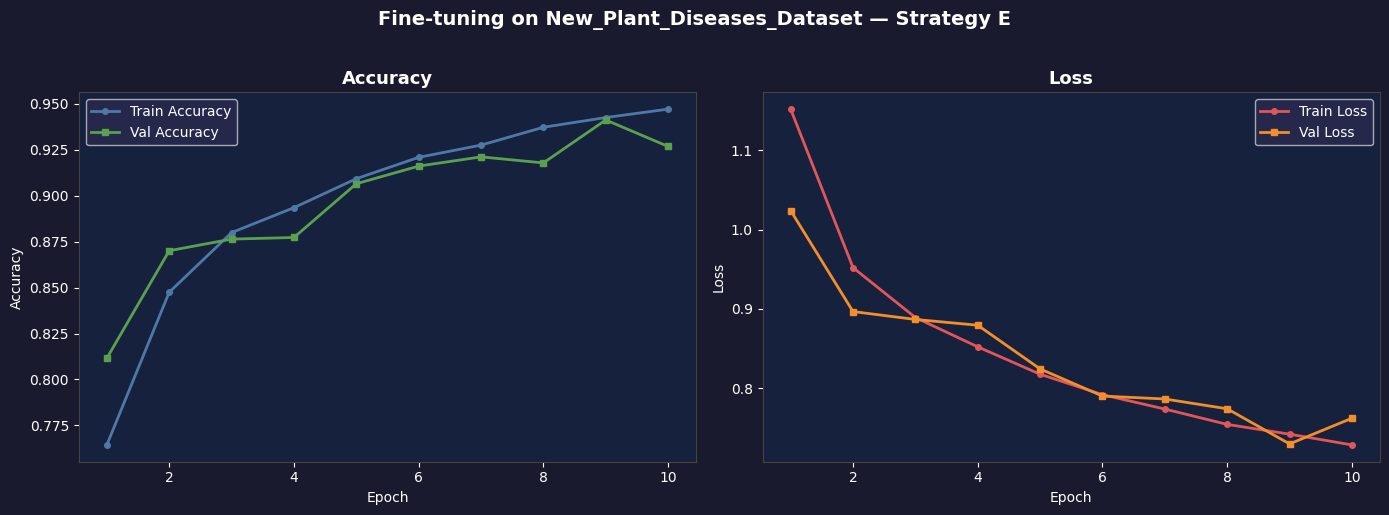

✅ Training curves saved: /media/bhanot/Main_Storage/Development/8th Sem Project/TomatoClassification/outputs/npdd_validation/finetune_training_curves.png


In [13]:
# ============================================================
# Cell 7 — Training Curves
#
# Plots accuracy and loss over epochs for both
# training and validation sets.
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#1a1a2e')
for ax in [ax1, ax2]:
    ax.set_facecolor('#16213e')

epochs_ran = range(1, len(history.history['accuracy']) + 1)

# ── Accuracy ──
ax1.plot(epochs_ran, history.history['accuracy'],
         color='#4e79a7', linewidth=2, marker='o', markersize=4, label='Train Accuracy')
ax1.plot(epochs_ran, history.history['val_accuracy'],
         color='#59a14f', linewidth=2, marker='s', markersize=4, label='Val Accuracy')
ax1.set_title('Accuracy', color='white', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch', color='white')
ax1.set_ylabel('Accuracy', color='white')
ax1.tick_params(colors='white')
ax1.legend(facecolor='#2a2a4e', labelcolor='white')
ax1.spines[:].set_color('#444')

# ── Loss ──
ax2.plot(epochs_ran, history.history['loss'],
         color='#e15759', linewidth=2, marker='o', markersize=4, label='Train Loss')
ax2.plot(epochs_ran, history.history['val_loss'],
         color='#f28e2b', linewidth=2, marker='s', markersize=4, label='Val Loss')
ax2.set_title('Loss', color='white', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch', color='white')
ax2.set_ylabel('Loss', color='white')
ax2.tick_params(colors='white')
ax2.legend(facecolor='#2a2a4e', labelcolor='white')
ax2.spines[:].set_color('#444')

fig.suptitle(
    'Fine-tuning on New_Plant_Diseases_Dataset — Strategy E',
    color='white', fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()

chart_path = OUTPUT_DIR / 'finetune_training_curves.png'
plt.savefig(chart_path, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f'✅ Training curves saved: {chart_path}')


In [14]:
# ============================================================
# Cell 8 — Evaluate Fine-tuned Model on Validation Set
#
# Runs inference on the full valid split (4 585 images) to
# confirm fine-tuning improved accuracy over the original
# Strategy E (93.88% internal benchmark).
# ============================================================

print('🔄 Running inference on validation set ...')
valid_gen.reset()
val_preds  = model.predict(valid_gen, verbose=1)
y_pred_val = np.argmax(val_preds, axis=1)
y_true_val = valid_gen.classes

val_acc = accuracy_score(y_true_val, y_pred_val)
print(f'\n✅ Validation Accuracy : {val_acc:.4f} ({val_acc:.2%})')
print(f'   Original Strategy E : 93.88%  (PlantVillage internal)')
print(f'   Delta               : {(val_acc - 0.9388)*100:+.2f}%')

print('\n📋 Classification Report (validation set):')
print('=' * 70)
print(classification_report(y_true_val, y_pred_val, target_names=CLASS_NAMES, digits=3))
print('=' * 70)


🔄 Running inference on validation set ...
144/144 ━━━━━━━━━━━━━━━━━━━━ 83s 572ms/step

✅ Validation Accuracy : 0.9411 (94.11%)
   Original Strategy E : 93.88%  (PlantVillage internal)
   Delta               : +0.23%

📋 Classification Report (validation set):
                    precision    recall  f1-score   support

    Bacterial Spot      0.946     0.953     0.950       425
      Early Blight      0.953     0.887     0.919       480
       Late Blight      0.956     0.942     0.949       463
         Leaf Mold      0.952     0.974     0.963       470
Septoria Leaf Spot      0.927     0.876     0.901       436
      Spider Mites      0.947     0.899     0.922       435
       Target Spot      0.823     0.943     0.879       457
  Yellow Leaf Curl      0.996     0.980     0.988       490
      Mosaic Virus      0.977     0.962     0.970       448
           Healthy      0.948     0.988     0.967       481

          accuracy                          0.941      4585
         macro avg 

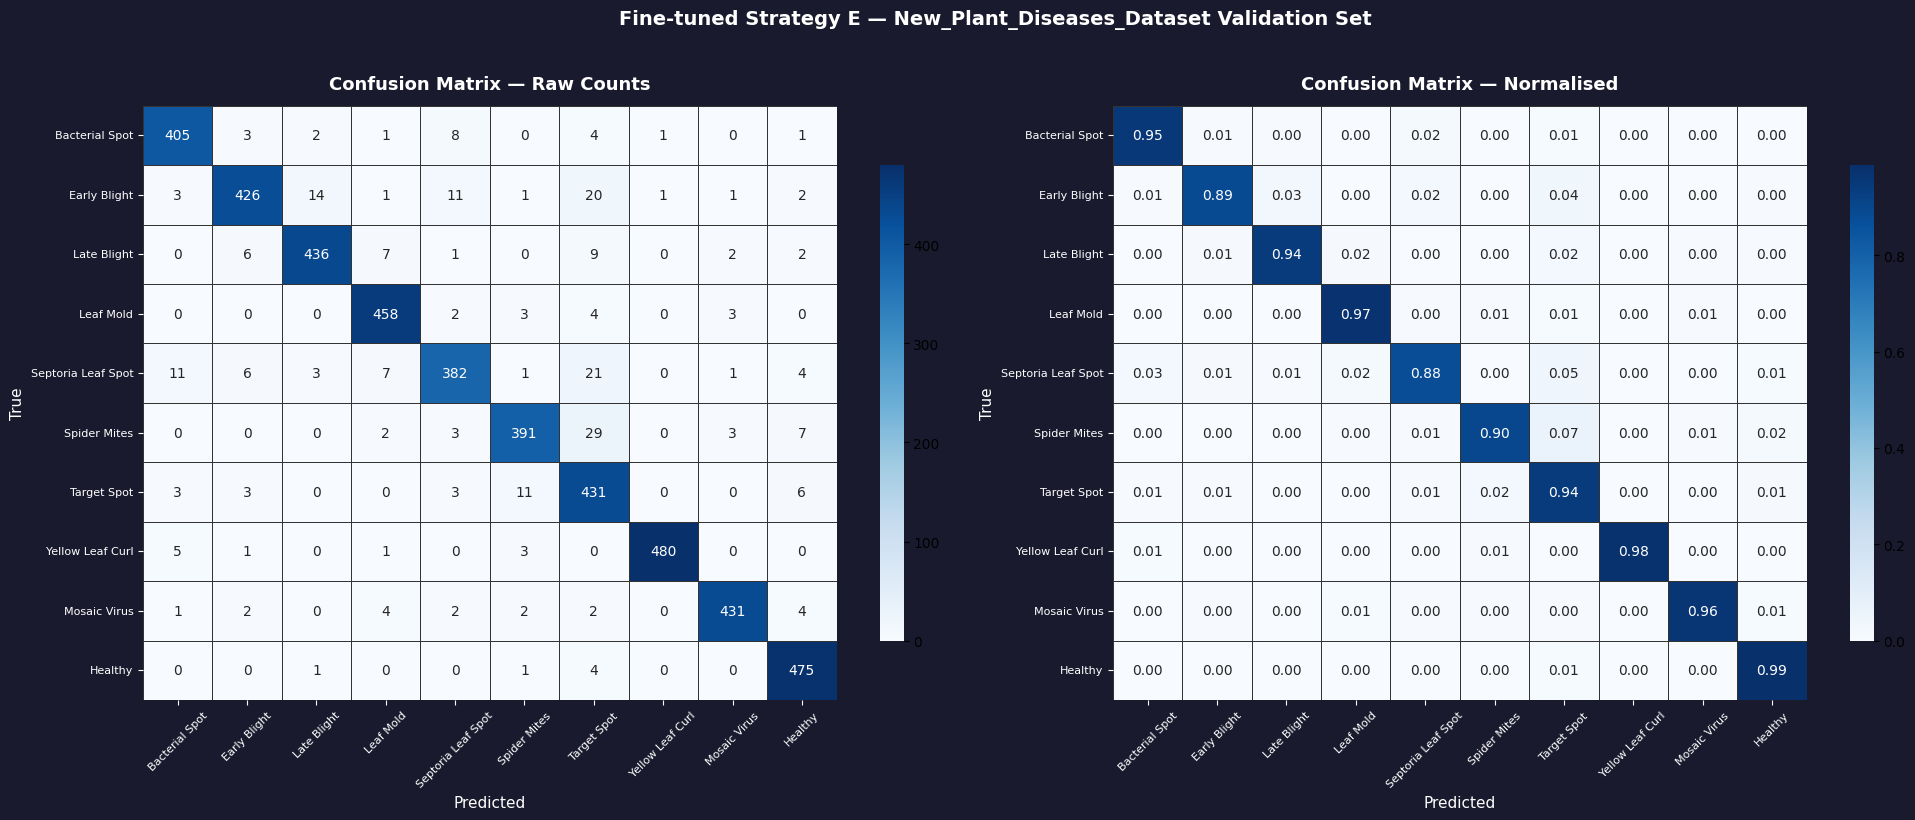

✅ Confusion matrix saved: /media/bhanot/Main_Storage/Development/8th Sem Project/TomatoClassification/outputs/npdd_validation/confusion_matrix_finetuned_valid.png


In [15]:
# ============================================================
# Cell 9 — Confusion Matrix (Validation Set)
# ============================================================

cm_val = confusion_matrix(y_true_val, y_pred_val)
cm_norm = cm_val.astype('float') / cm_val.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.patch.set_facecolor('#1a1a2e')

for ax, data, title, fmt in zip(
    axes,
    [cm_val, cm_norm],
    ['Confusion Matrix — Raw Counts', 'Confusion Matrix — Normalised'],
    ['d', '.2f']
):
    ax.set_facecolor('#16213e')
    sns.heatmap(
        data, ax=ax,
        annot=True, fmt=fmt,
        cmap='Blues',
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
        linewidths=0.5,
        linecolor='#333',
        cbar_kws={'shrink': 0.8},
    )
    ax.set_title(title, color='white', fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel('Predicted', color='white', fontsize=11)
    ax.set_ylabel('True', color='white', fontsize=11)
    ax.tick_params(axis='x', colors='white', rotation=45, labelsize=8)
    ax.tick_params(axis='y', colors='white', rotation=0, labelsize=8)

fig.suptitle(
    'Fine-tuned Strategy E — New_Plant_Diseases_Dataset Validation Set',
    color='white', fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()

cm_path = OUTPUT_DIR / 'confusion_matrix_finetuned_valid.png'
plt.savefig(cm_path, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f'✅ Confusion matrix saved: {cm_path}')


In [16]:
# ============================================================
# Cell 10 — Parse Flat Test Folder
#
# The test set is a FLAT folder (no class subfolders).
# Class labels are encoded in the filenames, e.g.:
#   TomatoEarlyBlight1.JPG   → class 1 (Early Blight)
#   TomatoHealthy3.JPG       → class 9 (Healthy)
#   TomatoYellowCurlVirus1.JPG → class 7 (Yellow Leaf Curl)
#
# We match each filename against FILENAME_TO_CLASS prefixes
# (longest match wins) to resolve the true label.
# ============================================================

def resolve_class(filename: str) -> int | None:
    """Match filename to class index via longest prefix match."""
    name = Path(filename).stem   # strip extension
    best_match, best_len = None, 0
    for prefix, idx in FILENAME_TO_CLASS.items():
        if name.startswith(prefix) and len(prefix) > best_len:
            best_match = idx
            best_len   = len(prefix)
    return best_match

# ── Scan the test folder ──
exts = {'.jpg', '.jpeg', '.JPG', '.JPEG', '.png', '.PNG'}
test_images = sorted([p for p in TEST_DIR.iterdir() if p.suffix in exts])

records = []
unresolved = []
for img_path in test_images:
    label = resolve_class(img_path.name)
    if label is None:
        unresolved.append(img_path.name)
    else:
        records.append({'path': img_path, 'true_label': label, 'class_name': CLASS_NAMES[label]})

print(f'📂 Test folder : {TEST_DIR}')
print(f'   Total images   : {len(test_images)}')
print(f'   Resolved       : {len(records)}')
print(f'   Unresolved     : {len(unresolved)}')
if unresolved:
    print('   ⚠️  Could not parse class from:', unresolved)

print('\n📋 Test images with resolved labels:')
print(f'  {"Filename":<35} {"True class":<25} Idx')
print('─' * 70)
for r in records:
    print(f'  {r["path"].name:<35} {r["class_name"]:<25} {r["true_label"]}')

from collections import Counter
dist = Counter(r['true_label'] for r in records)
print('\n📊 Class distribution in test set:')
for idx, count in sorted(dist.items()):
    print(f'  [{idx}] {CLASS_NAMES[idx]:<25} : {count} images')


📂 Test folder : /media/bhanot/Main_Storage/Development/8th Sem Project/TomatoClassification/validation/New_Plant_Diseases_Dataset/test/test
   Total images   : 33
   Resolved       : 16
   Unresolved     : 17
   ⚠️  Could not parse class from: ['AppleCedarRust1.JPG', 'AppleCedarRust2.JPG', 'AppleCedarRust3.JPG', 'AppleCedarRust4.JPG', 'AppleScab1.JPG', 'AppleScab2.JPG', 'AppleScab3.JPG', 'CornCommonRust1.JPG', 'CornCommonRust2.JPG', 'CornCommonRust3.JPG', 'PotatoEarlyBlight1.JPG', 'PotatoEarlyBlight2.JPG', 'PotatoEarlyBlight3.JPG', 'PotatoEarlyBlight4.JPG', 'PotatoEarlyBlight5.JPG', 'PotatoHealthy1.JPG', 'PotatoHealthy2.JPG']

📋 Test images with resolved labels:
  Filename                            True class                Idx
──────────────────────────────────────────────────────────────────────
  TomatoEarlyBlight1.JPG              Early Blight              1
  TomatoEarlyBlight2.JPG              Early Blight              1
  TomatoEarlyBlight3.JPG              Early Blight        

In [17]:
# ============================================================
# Cell 11 — Inference on Flat Test Set
#
# Uses preprocess_input (maps [0,255] → [-1,1]) to match
# the preprocessing used during fine-tuning.
# ============================================================

def predict_image(img_path: Path) -> tuple[int, float, np.ndarray]:
    """
    Load, preprocess, and predict a single image.
    Returns (predicted_class_idx, confidence, full_proba_vector).
    """
    img  = load_img(img_path, target_size=IMAGE_SIZE)
    arr  = img_to_array(img)                    # (224, 224, 3)  float32 [0, 255]
    arr  = preprocess_input(arr)                # (224, 224, 3)  float32 [-1, 1]
    arr  = np.expand_dims(arr, axis=0)          # (1, 224, 224, 3)
    prob = model.predict(arr, verbose=0)[0]     # (10,)
    pred = int(np.argmax(prob))
    conf = float(prob[pred])
    return pred, conf, prob

# ── Run inference ──
print('🔄 Running inference on test set ...')
results = []
for r in records:
    pred, conf, prob = predict_image(r['path'])
    correct = (pred == r['true_label'])
    results.append({
        'filename'   : r['path'].name,
        'true_idx'   : r['true_label'],
        'true_class' : r['class_name'],
        'pred_idx'   : pred,
        'pred_class' : CLASS_NAMES[pred],
        'confidence' : conf,
        'correct'    : correct,
        'prob_vector': prob,
    })

y_true_test = [r['true_idx'] for r in results]
y_pred_test = [r['pred_idx'] for r in results]

test_acc = accuracy_score(y_true_test, y_pred_test)
avg_conf  = np.mean([r['confidence'] for r in results])

print(f'\n✅ Test set results:')
print(f'   Images evaluated : {len(results)}')
print(f'   Accuracy         : {test_acc:.4f}  ({test_acc:.2%})')
print(f'   Avg confidence   : {avg_conf:.4f}  ({avg_conf:.2%})')


🔄 Running inference on test set ...

✅ Test set results:
   Images evaluated : 16
   Accuracy         : 1.0000  (100.00%)
   Avg confidence   : 0.7554  (75.54%)


In [18]:
# ============================================================
# Cell 12 — Per-Image Results Table
# ============================================================

print('\n📋 Per-Image Predictions')
print('=' * 90)
print(f'  {"File":<38} {"True":<22} {"Predicted":<22} {"Conf":>7}  OK?')
print('─' * 90)

for r in results:
    mark = '✅' if r['correct'] else '❌'
    print(
        f'  {r["filename"]:<38} '
        f'{r["true_class"]:<22} '
        f'{r["pred_class"]:<22} '
        f'{r["confidence"]:>7.2%}  {mark}'
    )

print('─' * 90)
correct_count = sum(r['correct'] for r in results)
print(f'  Total: {correct_count}/{len(results)} correct  →  {test_acc:.2%} accuracy')
print('=' * 90)



📋 Per-Image Predictions
  File                                   True                   Predicted                 Conf  OK?
──────────────────────────────────────────────────────────────────────────────────────────
  TomatoEarlyBlight1.JPG                 Early Blight           Early Blight            39.45%  ✅
  TomatoEarlyBlight2.JPG                 Early Blight           Early Blight            89.22%  ✅
  TomatoEarlyBlight3.JPG                 Early Blight           Early Blight            32.50%  ✅
  TomatoEarlyBlight4.JPG                 Early Blight           Early Blight            34.94%  ✅
  TomatoEarlyBlight5.JPG                 Early Blight           Early Blight            77.88%  ✅
  TomatoEarlyBlight6.JPG                 Early Blight           Early Blight            46.87%  ✅
  TomatoHealthy1.JPG                     Healthy                Healthy                 98.37%  ✅
  TomatoHealthy2.JPG                     Healthy                Healthy                 97.48%  ✅


In [19]:
# ============================================================
# Cell 13 — Classification Report (Test Set)
#
# Note: only classes present in the test set are shown.
# Missing classes (not in test set) are excluded automatically.
# ============================================================

classes_in_test = sorted(set(y_true_test))
names_in_test   = [CLASS_NAMES[i] for i in classes_in_test]

print('📋 Classification Report — Fine-tuned Strategy E on New_Plant_Diseases test set')
print('=' * 70)
print(classification_report(
    y_true_test, y_pred_test,
    labels=classes_in_test,
    target_names=names_in_test,
    digits=3,
    zero_division=0,
))
print('=' * 70)
print(f'\nNote: Only {len(classes_in_test)} of 10 classes appear in the flat test set.')
print(f'Classes present: {names_in_test}')


📋 Classification Report — Fine-tuned Strategy E on New_Plant_Diseases test set
                  precision    recall  f1-score   support

    Early Blight      1.000     1.000     1.000         6
Yellow Leaf Curl      1.000     1.000     1.000         6
         Healthy      1.000     1.000     1.000         4

        accuracy                          1.000        16
       macro avg      1.000     1.000     1.000        16
    weighted avg      1.000     1.000     1.000        16


Note: Only 3 of 10 classes appear in the flat test set.
Classes present: ['Early Blight', 'Yellow Leaf Curl', 'Healthy']


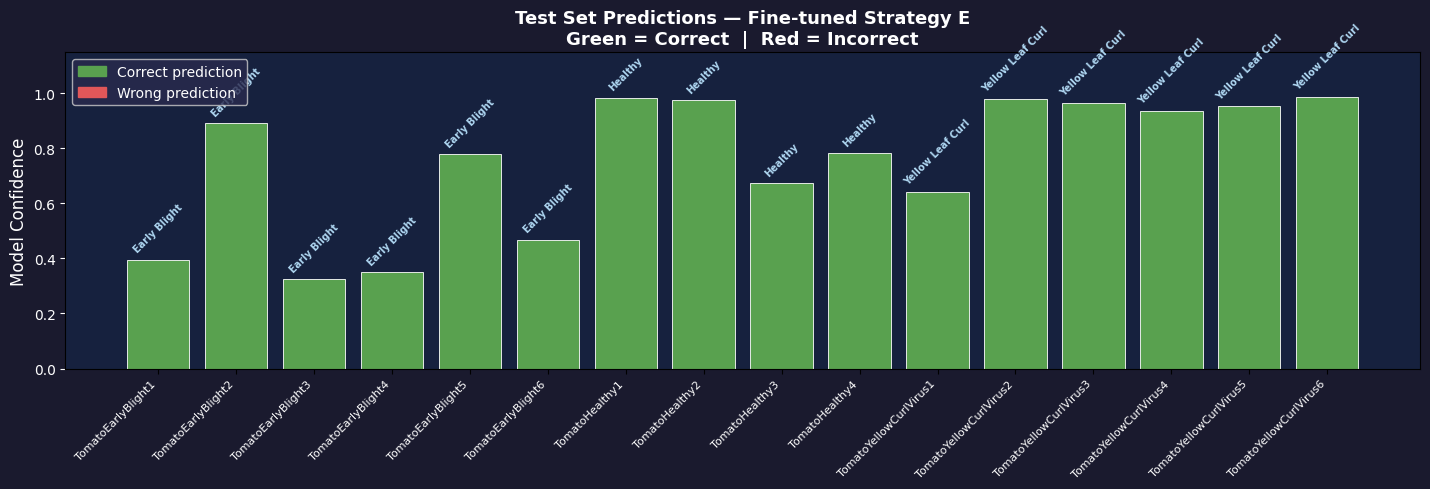

✅ Chart saved: /media/bhanot/Main_Storage/Development/8th Sem Project/TomatoClassification/outputs/npdd_validation/test_predictions_bar_chart.png


In [20]:
# ============================================================
# Cell 14 — Bar Chart: True vs Predicted per test image
# ============================================================

fig, ax = plt.subplots(figsize=(max(14, len(results) * 0.9), 5))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#16213e')

x = np.arange(len(results))
colors = ['#59a14f' if r['correct'] else '#e15759' for r in results]
bars  = ax.bar(x, [r['confidence'] for r in results], color=colors, edgecolor='white', linewidth=0.6)

ax.set_xticks(x)
ax.set_xticklabels(
    [r['filename'].replace('.JPG', '').replace('.jpg', '') for r in results],
    rotation=45, ha='right', fontsize=8, color='white'
)
ax.set_ylim([0, 1.15])
ax.set_ylabel('Model Confidence', color='white', fontsize=12)
ax.set_title(
    'Test Set Predictions — Fine-tuned Strategy E\n'
    'Green = Correct  |  Red = Incorrect',
    color='white', fontsize=13, fontweight='bold'
)
ax.tick_params(axis='y', colors='white')

# Annotate each bar with predicted class
for i, r in enumerate(results):
    ax.text(
        i, r['confidence'] + 0.02,
        r['pred_class'],
        ha='center', va='bottom', fontsize=7,
        color='#aed6f1' if r['correct'] else '#f1948a',
        fontweight='bold', rotation=45,
    )

# Legend
green_patch = mpatches.Patch(color='#59a14f', label='Correct prediction')
red_patch   = mpatches.Patch(color='#e15759', label='Wrong prediction')
ax.legend(handles=[green_patch, red_patch], facecolor='#2a2a4e', labelcolor='white')

plt.tight_layout()
chart_path = OUTPUT_DIR / 'test_predictions_bar_chart.png'
plt.savefig(chart_path, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f'✅ Chart saved: {chart_path}')


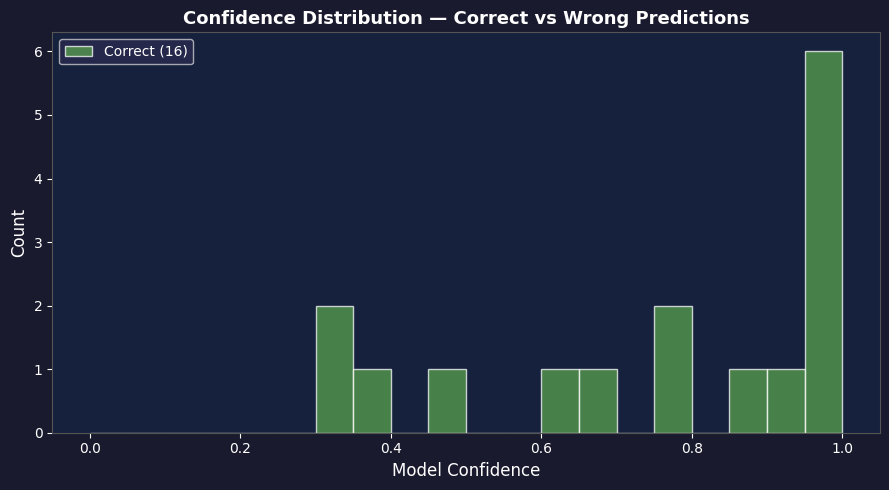

✅ Histogram saved: /media/bhanot/Main_Storage/Development/8th Sem Project/TomatoClassification/outputs/npdd_validation/test_confidence_distribution.png


In [21]:
# ============================================================
# Cell 15 — Confidence Distribution: Correct vs Wrong
# ============================================================

correct_conf = [r['confidence'] for r in results if r['correct']]
wrong_conf   = [r['confidence'] for r in results if not r['correct']]

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#16213e')

bins = np.linspace(0, 1, 21)
if correct_conf:
    ax.hist(correct_conf, bins=bins, alpha=0.75, color='#59a14f', label=f'Correct ({len(correct_conf)})', edgecolor='white')
if wrong_conf:
    ax.hist(wrong_conf,   bins=bins, alpha=0.75, color='#e15759', label=f'Wrong ({len(wrong_conf)})',   edgecolor='white')

ax.set_xlabel('Model Confidence', color='white', fontsize=12)
ax.set_ylabel('Count', color='white', fontsize=12)
ax.set_title('Confidence Distribution — Correct vs Wrong Predictions', color='white', fontsize=13, fontweight='bold')
ax.tick_params(colors='white')
ax.legend(facecolor='#2a2a4e', labelcolor='white')
ax.spines[:].set_color('#555')

plt.tight_layout()
hist_path = OUTPUT_DIR / 'test_confidence_distribution.png'
plt.savefig(hist_path, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f'✅ Histogram saved: {hist_path}')


In [22]:
# ============================================================
# Cell 16 — Export Results to CSV
# ============================================================

rows = []
for r in results:
    row = {
        'filename'    : r['filename'],
        'true_class'  : r['true_class'],
        'true_idx'    : r['true_idx'],
        'pred_class'  : r['pred_class'],
        'pred_idx'    : r['pred_idx'],
        'confidence'  : round(r['confidence'], 4),
        'correct'     : r['correct'],
    }
    # Add per-class probability
    for i, cls in enumerate(CLASS_NAMES):
        row[f'prob_{cls.lower().replace(" ", "_")}'] = round(float(r['prob_vector'][i]), 4)
    rows.append(row)

df = pd.DataFrame(rows)
csv_path = OUTPUT_DIR / 'test_predictions_NPDD.csv'
df.to_csv(csv_path, index=False)

print(f'✅ Results saved: {csv_path}')
print(f'   Rows     : {len(df)}')
print(f'   Columns  : {list(df.columns[:7])} + {len(df.columns)-7} prob columns')
print()
print(df[['filename', 'true_class', 'pred_class', 'confidence', 'correct']].to_string(index=False))


✅ Results saved: /media/bhanot/Main_Storage/Development/8th Sem Project/TomatoClassification/outputs/npdd_validation/test_predictions_NPDD.csv
   Rows     : 16
   Columns  : ['filename', 'true_class', 'true_idx', 'pred_class', 'pred_idx', 'confidence', 'correct'] + 10 prob columns

                  filename       true_class       pred_class  confidence  correct
    TomatoEarlyBlight1.JPG     Early Blight     Early Blight      0.3945     True
    TomatoEarlyBlight2.JPG     Early Blight     Early Blight      0.8922     True
    TomatoEarlyBlight3.JPG     Early Blight     Early Blight      0.3250     True
    TomatoEarlyBlight4.JPG     Early Blight     Early Blight      0.3494     True
    TomatoEarlyBlight5.JPG     Early Blight     Early Blight      0.7788     True
    TomatoEarlyBlight6.JPG     Early Blight     Early Blight      0.4687     True
        TomatoHealthy1.JPG          Healthy          Healthy      0.9837     True
        TomatoHealthy2.JPG          Healthy          Healthy 

In [23]:
# ============================================================
# Cell 17 — Final Summary
# ============================================================

print('=' * 65)
print('  📝  FINE-TUNE + TEST SUMMARY — New_Plant_Diseases_Dataset')
print('=' * 65)

best_val_acc_val = max(history.history['val_accuracy'])
print(f'\n  🏋️  Fine-tuning')
print(f'     Dataset         : New_Plant_Diseases_Dataset/train')
print(f'     Train images    : {train_gen.samples:,}  ({len(train_gen.class_indices)} classes)')
print(f'     Valid images    : {valid_gen.samples:,}')
print(f'     Epochs ran      : {len(history.history["accuracy"])}  (max={EPOCHS})')
print(f'     Best val acc    : {best_val_acc_val:.4f} ({best_val_acc_val:.2%})')
print(f'     Saved model     : {FINETUNED_PATH.name}')

print(f'\n  🧪  Test Set Evaluation')
print(f'     Dataset         : New_Plant_Diseases_Dataset/test/test/')
print(f'     Images evaluated: {len(results)}  (tomato only, flat folder)')
print(f'     Test Accuracy   : {test_acc:.4f}  ({test_acc:.2%})')
print(f'     Avg Confidence  : {avg_conf:.4f}  ({avg_conf:.2%})')
correct_count = sum(r["correct"] for r in results)
print(f'     Correct / Total : {correct_count} / {len(results)}')

print(f'\n  📁  Outputs saved to:')
print(f'     {OUTPUT_DIR}')
for f in sorted(OUTPUT_DIR.iterdir()):
    print(f'       {f.name}')

print('\n' + '=' * 65)


  📝  FINE-TUNE + TEST SUMMARY — New_Plant_Diseases_Dataset

  🏋️  Fine-tuning
     Dataset         : New_Plant_Diseases_Dataset/train
     Train images    : 18,345  (10 classes)
     Valid images    : 4,585
     Epochs ran      : 10  (max=10)
     Best val acc    : 0.9411 (94.11%)
     Saved model     : model_E_finetuned_NPDD_final.h5

  🧪  Test Set Evaluation
     Dataset         : New_Plant_Diseases_Dataset/test/test/
     Images evaluated: 16  (tomato only, flat folder)
     Test Accuracy   : 1.0000  (100.00%)
     Avg Confidence  : 0.7554  (75.54%)
     Correct / Total : 16 / 16

  📁  Outputs saved to:
     /media/bhanot/Main_Storage/Development/8th Sem Project/TomatoClassification/outputs/npdd_validation
       confusion_matrix_finetuned_valid.png
       finetune_training_curves.png
       test_confidence_distribution.png
       test_predictions_NPDD.csv
       test_predictions_bar_chart.png

